# Load libraries and data

In [1]:
import matplotlib.pyplot as plt
import dask.dataframe as dd
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
df_jan = dd.read_csv("../data/external/yellow_tripdata_2016-01.csv", assume_missing=True)
df_feb = dd.read_csv("../data/external/yellow_tripdata_2016-02.csv", assume_missing=True)
df_mar = dd.read_csv("../data/external/yellow_tripdata_2016-03.csv", assume_missing=True)

In [ ]:
# number of partitions are 26 for each month and column names along with data types of columns
df_jan

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
npartitions=26,,,,,,,,,,,,,,,,,,,
,float64,string,string,float64,float64,float64,float64,float64,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


#### Attributes

- **VendorID**: A code indicating the TPEP provider that provided the record. Here, there are two providers `1` means `Creative Mobile Technologies` and `2` means `VeriFone Inc`.
- **tpep_pickup_datetime**: The date and time when the meter was engaged.
- **tpep_dropoff_datetime**: The date and time when the meter was disengaged.
- **Passenger_count**: The number of passengers in the vehicle. This is a driver- entered value.

- **Trip_distance**: The elapsed trip distance in miles reported by the taximeter.
- **Pickup_longitude**: Longitude where the meter was engaged.
- **Pickup_latitude**: Latitude where the meter was engaged.
- **RateCodeID**: The final rate code in effect at the end of the trip. Categorical variables are `1` means `Standard rate`, `2` means `JFK`, `3` means `Newark`, `4` means `Nassau or Westchester`, `5` means `Negotiated fare`, `6` means `Group ride`.

- **Store_and_fwd_flag**: This flag indicates whether the trip record was held in vehicle memory before sending to the vendor,
aka "store and forward," because the vehicle did not have a connection to the server. Categories are `Y` means `store and forward trip` and `N` means `not a store and forward trip`.
- **Dropoff_longitude**: Longitude where the meter was disengaged.
- **Dropoff_latitude**: Latitude where the meter was disengaged.

- **Payment_type**: A numeric code signifying how the passenger paid for the trip. Categoires are `1` means `Credit card`, `2` means `Cash`, `3` means `No charge`, `4` means `Dispute`, `5` means `Unknown`, `6` means `Voided trip`.
- **Fare_amount**: The time-and-distance fare calculated by the meter.
- **Extra**: Miscellaneous extras and surcharges. Currently, this only includes. the $0.50 and $1 rush hour and overnight charges.
- **MTA_tax**: 0.50 MTA tax that is automatically triggered based on the metered rate in use.

- **Tip_amount**: Tip amount - This field is automatically populated for credit card tips.Cash tips are not included.
- **Tolls_amount**: Total amount of all tolls paid in trip.
- **Improvement_surcharge**: 0.30 improvement surcharge assessed trips at the flag drop. the improvement surcharge began being levied in 2015.
- **Total_amount**: The total amount charged to passengers. Does not include cash tips.

Features like Payment_type, Fare_amount, Extra, MTA_tax, Tip_amount, Tolls_amount, Improvement_surcharge and Total_amount are not relevant for demand prediction and will be dropped from the dataset.
This might be useful for fare prediction but not for demand prediction. We are only focusing on columns created before the trip starts and columns created after the trip ends can be used for fare prediction, but not for demand prediction.

# checking

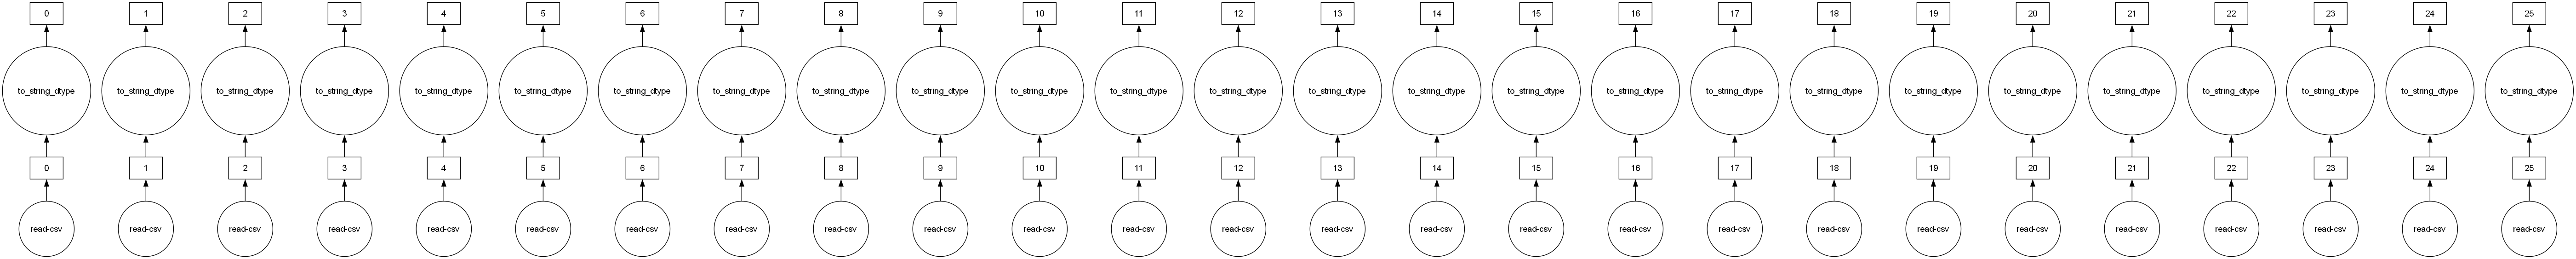

In [ ]:
# visualize the chunks using the task graph when tasks=True, show flowchart when tasks=False

df_jan.visualize(tasks=True)

In [5]:
# shape of all the three datasets

print("Shape of january dataset", df_jan.shape)
print("Shape of february dataset", df_feb.shape)
print("Shape of march dataset", df_mar.shape)

Shape of january dataset (<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(bfaa4ba)).size() // 19, dtype=int64>, 19)
Shape of february dataset (<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(ba4205c)).size() // 19, dtype=int64>, 19)
Shape of march dataset (<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(8e39193)).size() // 19, dtype=int64>, 19)


**We can concat the three dataframes as the number of columns are same in all the three dfs**

In [6]:
# concat the three dataframes as one

df_final = dd.concat([df_jan, df_feb, df_mar], axis=0).drop(columns=['extra', 'mta_tax', 'tip_amount', 'tolls_amount',
       'improvement_surcharge', 'total_amount', 'payment_type'])
# droping unnecessary columns 

In [ ]:
df_final
# now number of partitions are 82 after concatenating three months of data

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,fare_amount
npartitions=82,,,,,,,,,,,,
,float64,string,string,float64,float64,float64,float64,float64,string,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...


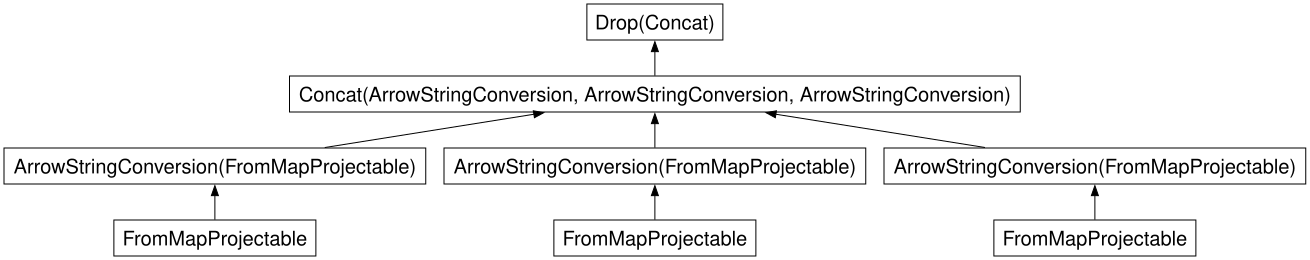

In [ ]:
# visulaize the concatenated dataframe

df_final.visualize()

In [9]:
# columns in the final dataset

df_final.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'fare_amount'],
      dtype='str')

In [ ]:
# NOTE: head has compute method as default

df_final.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,fare_amount
0,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,2.0,1.10,-73.990372,40.734695,1.0,N,-73.981842,40.732407,7.5
1,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,5.0,4.90,-73.980782,40.729912,1.0,N,-73.944473,40.716679,18.0
2,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,1.0,10.54,-73.984550,40.679565,1.0,N,-73.950272,40.788925,33.0
3,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,1.0,4.75,-73.993469,40.718990,1.0,N,-73.962242,40.657333,16.5
4,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,3.0,1.76,-73.960625,40.781330,1.0,N,-73.977264,40.758514,8.0
5,2.0,2016-01-01 00:00:00,2016-01-01 00:18:30,2.0,5.52,-73.980118,40.743050,1.0,N,-73.913490,40.763142,19.0
6,2.0,2016-01-01 00:00:00,2016-01-01 00:26:45,2.0,7.45,-73.994057,40.719990,1.0,N,-73.966362,40.789871,26.0
7,1.0,2016-01-01 00:00:01,2016-01-01 00:11:55,1.0,1.20,-73.979424,40.744614,1.0,N,-73.992035,40.753944,9.0
8,1.0,2016-01-01 00:00:02,2016-01-01 00:11:14,1.0,6.00,-73.947151,40.791046,1.0,N,-73.920769,40.865578,18.0
9,2.0,2016-01-01 00:00:02,2016-01-01 00:11:08,1.0,3.21,-73.998344,40.723896,1.0,N,-73.995850,40.688400,11.5


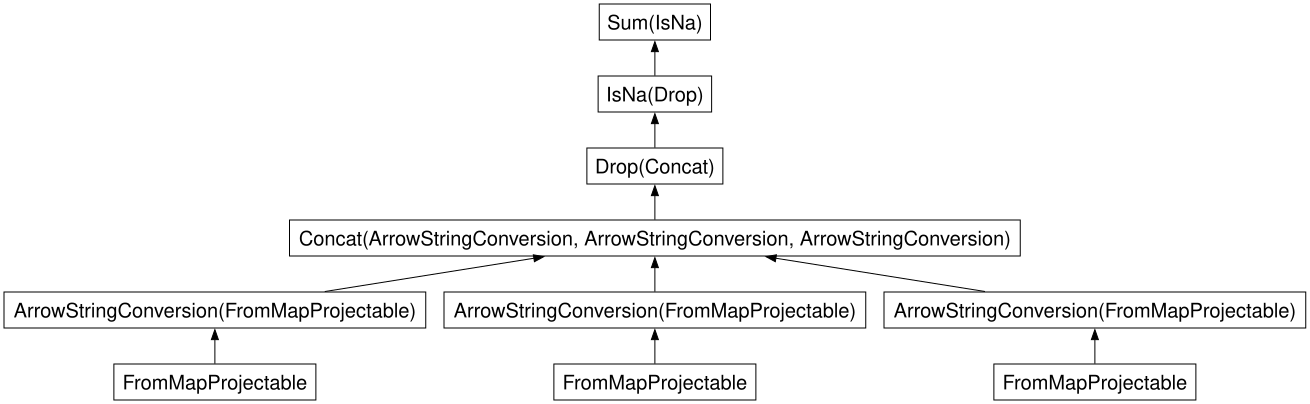

In [11]:
df_final.isna().sum().visualize()

In [12]:
# check for missing values in the data

df_final.isna().sum().compute()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
fare_amount              0
dtype: int64

**There are no missing values in the data**

In [13]:
# datatypes

df_final.dtypes

VendorID                 float64
tpep_pickup_datetime      string
tpep_dropoff_datetime     string
passenger_count          float64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RatecodeID               float64
store_and_fwd_flag        string
dropoff_longitude        float64
dropoff_latitude         float64
fare_amount              float64
dtype: object

# Analysis

In [14]:
sns.set_style("whitegrid")

In [15]:
# statistical summary of numerical columns

df_final.describe().compute()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,fare_amount
count,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07
mean,1.532576e+00,1.661700e+00,5.309408e+00,-7.283942e+01,4.012605e+01,1.039150e+00,-7.290482e+01,4.016297e+01,1.257198e+01
std,4.989377e-01,1.316154e+00,4.672575e+03,9.090656e+00,5.007832e+00,5.564537e-01,8.828348e+00,4.863875e+00,9.179006e+01
min,1.000000e+00,0.000000e+00,-3.390584e+06,-1.616987e+02,-7.703949e+01,1.000000e+00,-1.616987e+02,-7.703949e+01,-9.576000e+02
25%,1.000000e+00,1.000000e+00,1.100000e+00,-7.399055e+01,4.074137e+01,1.000000e+00,-7.399009e+01,4.074001e+01,7.000000e+00
50%,2.000000e+00,1.000000e+00,1.930000e+00,-7.397922e+01,4.075640e+01,1.000000e+00,-7.397832e+01,4.075612e+01,1.000000e+01
75%,2.000000e+00,2.000000e+00,3.800000e+00,-7.396252e+01,4.076979e+01,1.000000e+00,-7.395599e+01,4.077166e+01,1.550000e+01
max,2.000000e+00,9.000000e+00,1.907263e+07,9.464387e+01,6.685682e+01,9.900000e+01,3.889659e+01,4.053167e+02,4.294967e+05


NOTE: For USA, longitude is negative as it is in western hemisphere and latitude is positive as it is in northern hemisphere. Thus, any positive longitude or negative latitude is an outlier.

`trip_distance`: Mean distance is 5.3 miles while median is 1.93 miles. the column is right skewed as mean is greater than median. Maximum distance is 19,072,630 miles which is too big thus an outlier.
`pickup_longitude`: Maximum value is 94 i.e. positive thus an outlier. Minimum is -161 is too small thus an outlier.
`pickup_latitude`: Minimum value is -77 i.e. negative thus an outlier.
`dropoff_longitude`: Maximum value is 38 i.e. positive thus an outlier. Minimum is -161 is too small thus an outlier.
`dropoff_latitude`: Minimum value is -77 i.e. negative thus an outlier. Maximum is 405 is too big thus an outlier.
`fare_amount`: Mean is 12.5 and median is 10. While maximum is 429496 which is too high thus an outlier.

## Vendor ID

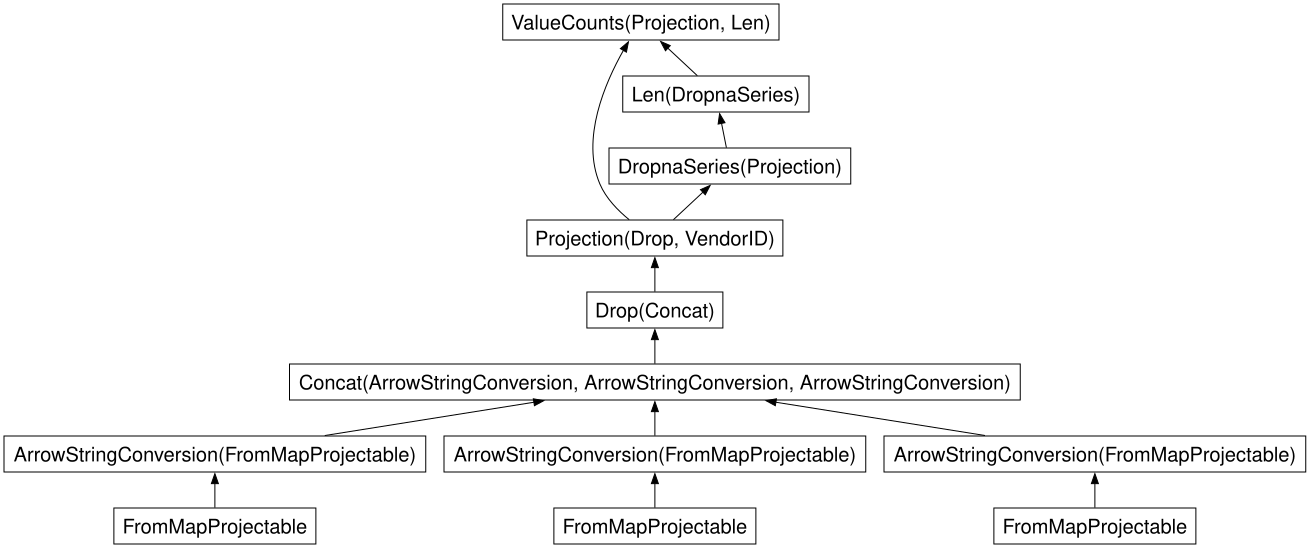

In [16]:
df_final["VendorID"].value_counts(normalize=True).visualize()

In [17]:
# pie chart of vendor share in NYC

vendor_share = (
    df_final["VendorID"]
    .value_counts(normalize=True)
    .compute()
)

In [57]:
vendor_share

VendorID
2.0    0.532576
1.0    0.467424
Name: proportion, dtype: float64

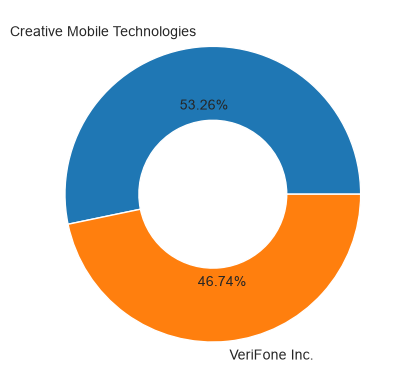

In [19]:
# donut chart

plt.pie(vendor_share, labels=["Creative Mobile Technologies","VeriFone Inc."], autopct="%.2f%%",
       radius=1, wedgeprops=dict(width=0.5, edgecolor="w"))
plt.show()

## Passenger Count

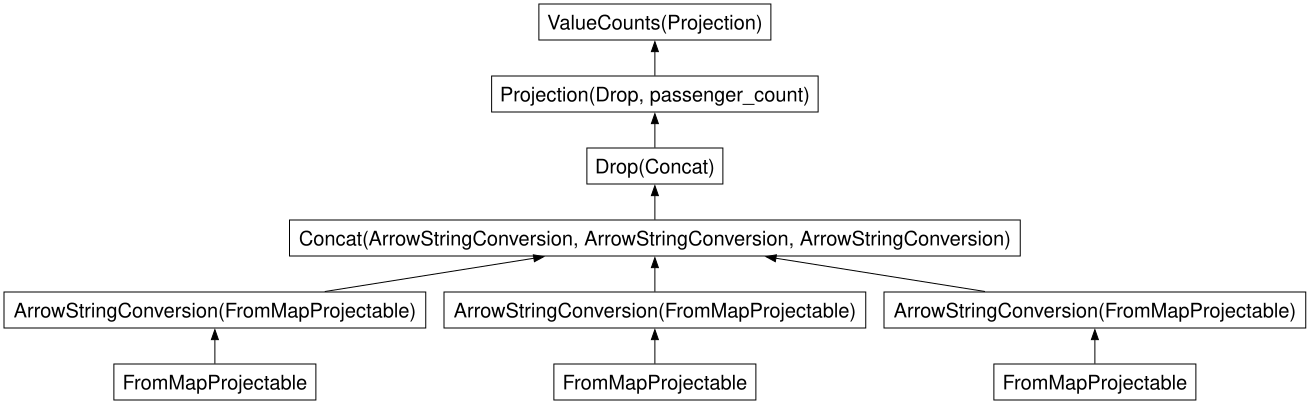

In [20]:
df_final["passenger_count"].value_counts().visualize()

In [21]:
# countplot for passenger plot

passenger_count = df_final["passenger_count"].value_counts().compute()

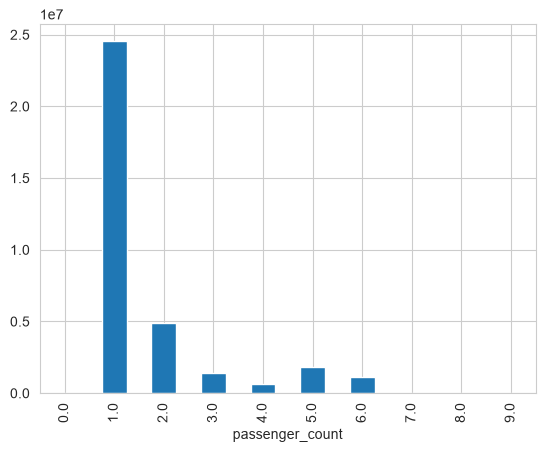

In [22]:
passenger_count.sort_index().plot(kind="bar")
plt.show()

**Passenger count value outside the range of 1 to 5 passengers are erroneous and not allowed by the taxi commission in NYC**

But, we will be droping the column as it is not relevant for demand prediction.

## Trip Distance

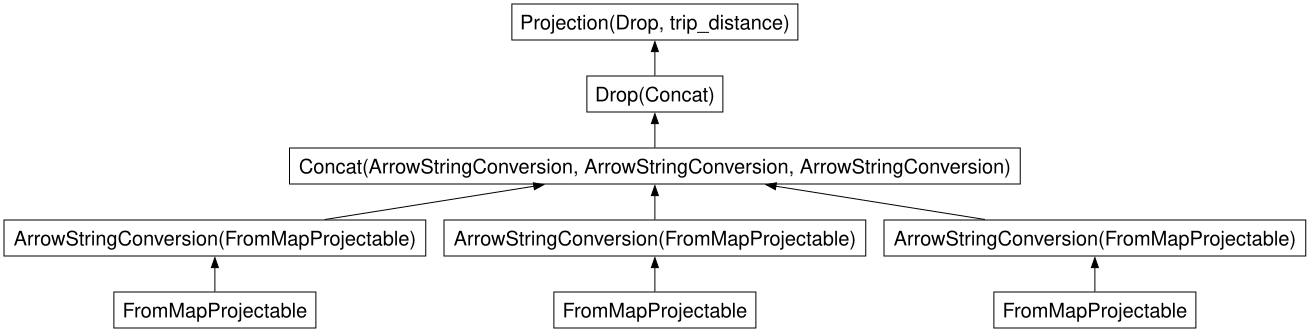

In [ ]:
df_final.loc[:, "trip_distance"].visualize()

<Axes: ylabel='trip_distance'>

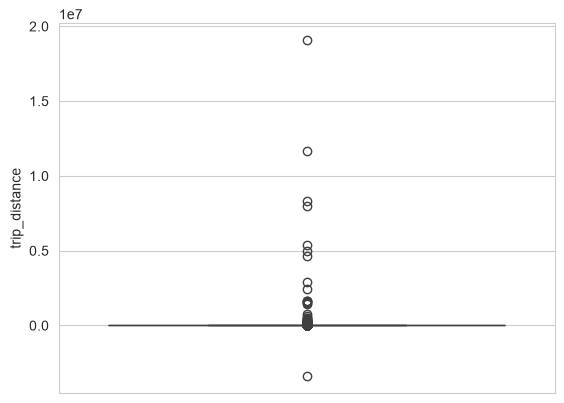

In [ ]:
# boxplot for the trip distance

sns.boxplot(df_final.loc[:, "trip_distance"].compute())

Outliers values in trip_distance can be seen in the box plot.

In [25]:
df_final["trip_distance"]

Dask Series Structure:
npartitions=82
    float64
        ...
     ...   
        ...
        ...
Dask Name: getitem, 9 expressions
Expr=(Drop(frame=Concat(frames=[ArrowStringConversion(frame=FromMapProjectable(bfaa4ba)), ArrowStringConversion(frame=FromMapProjectable(ba4205c)), ArrowStringConversion(frame=FromMapProjectable(8e39193))], ), columns=['extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'payment_type']))['trip_distance']

In [ ]:
# percentile values for trip distance

percentile_values = np.arange(0.1, 1.0, 0.1)
percentile_values

for percentile in percentile_values:
    print(f"The trip distance value for {int(percentile * 100)}th percentile is {df_final['trip_distance'].quantile(q=percentile).compute()}")

The trip distance value for 10th percentile is 0.7
The trip distance value for 20th percentile is 0.97
The trip distance value for 30th percentile is 1.23
The trip distance value for 40th percentile is 1.56
The trip distance value for 50th percentile is 1.93
The trip distance value for 60th percentile is 2.49
The trip distance value for 70th percentile is 3.27
The trip distance value for 80th percentile is 4.6
The trip distance value for 90th percentile is 8.3


No outliers from 0.1 to 0.9 percentile values

In [ ]:
percentile_values = np.arange(0.90, 1.01, 0.01)
percentile_values

for percentile in percentile_values:
    print(f"The trip distance value for {int(percentile * 100)}th percentile is {df_final['trip_distance'].quantile(q=percentile).compute()}")


The trip distance value for 90th percentile is 8.3
The trip distance value for 91th percentile is 8.91
The trip distance value for 92th percentile is 9.53
The trip distance value for 93th percentile is 10.2
The trip distance value for 94th percentile is 10.95
The trip distance value for 95th percentile is 12.1
The trip distance value for 96th percentile is 14.680000000000582
The trip distance value for 97th percentile is 16.91
The trip distance value for 98th percentile is 17.95
The trip distance value for 99th percentile is 19.375500000000464
The trip distance value for 100th percentile is 19072628.8


from 0.9 to 0.99 percentile, there is no outliers but there is outliers from 0.99 to 1.0 percentile values. We have to remove these outliers.

## Fare Amount

<Axes: ylabel='fare_amount'>

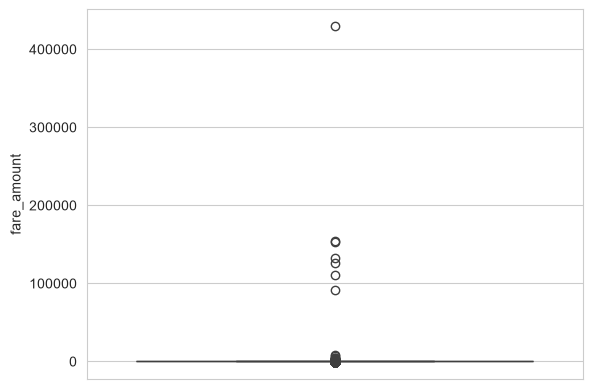

In [ ]:
# boxplot for the fare amount

sns.boxplot(df_final.loc[:, "fare_amount"].compute())

Clearly fare_amount column contains outliers

In [ ]:
# percentile values for fare amount

percentile_values = np.arange(0.1, 1.1, 0.1)
percentile_values

for percentile in percentile_values:
    print(f"The fare amount value for {int(percentile * 100)}th percentile is {df_final['fare_amount'].quantile(q=percentile).compute()}")

The fare amount value for 10th percentile is 5.0
The fare amount value for 20th percentile is 6.0
The fare amount value for 30th percentile is 7.5
The fare amount value for 40th percentile is 8.5
The fare amount value for 50th percentile is 10.0
The fare amount value for 60th percentile is 11.5
The fare amount value for 70th percentile is 14.0
The fare amount value for 80th percentile is 18.0
The fare amount value for 90th percentile is 27.0
The fare amount value for 100th percentile is 429496.72


from 0.1 to 0.9 percentile, there is no outliers but there is outliers from 0.9 to 1.0 percentile values.

In [ ]:
percentile_values = np.arange(0.90, 1.01, 0.01)
percentile_values

for percentile in percentile_values:
    print(f"The fare amount value for {int(percentile * 100)}th percentile is {df_final['fare_amount'].quantile(q=percentile).compute()}")


The fare amount value for 90th percentile is 27.0
The fare amount value for 91th percentile is 29.0
The fare amount value for 92th percentile is 30.5
The fare amount value for 93th percentile is 33.0
The fare amount value for 94th percentile is 35.5
The fare amount value for 95th percentile is 40.0
The fare amount value for 96th percentile is 49.5
The fare amount value for 97th percentile is 52.0
The fare amount value for 98th percentile is 52.0
The fare amount value for 99th percentile is 52.0
The fare amount value for 100th percentile is 429496.72


from 0.9 to 0.99 percentile, there is no outliers but there is outliers from 0.99 to 1.0 percentile values. We have to remove these outliers.

## RateCode ID

In [33]:
# unique values

rate_code_ids = (
    df_final.loc[:,"RatecodeID"]
    .value_counts()
    .compute()
)

In [34]:
rate_code_ids.sort_index()

RatecodeID
1.0     33627000
2.0       697595
3.0        56169
4.0        14459
5.0       103481
6.0          320
99.0         835
Name: count, dtype: int64

In [35]:
# unique values in rate code column

print(rate_code_ids.sort_index().index.tolist())

[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 99.0]


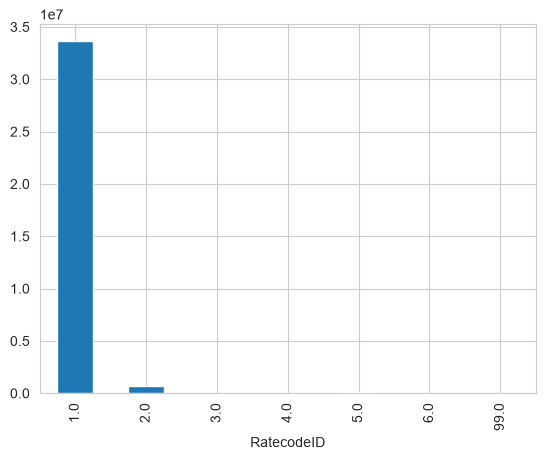

In [36]:
# plot the bar plot to display the distribution of categories

rate_code_ids.sort_index().plot(kind="bar")
plt.show()

**Missing values category is replaced by 99**

We will be dropping the column as it is not relevant for demand prediction.

## Location Based Columns

In [ ]:
# make a subset of location based columns

location_subset = df_final[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']]
location_subset

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
npartitions=82,,,,
,float64,float64,float64,float64
,...,...,...,...
...,...,...,...,...
,...,...,...,...
,...,...,...,...


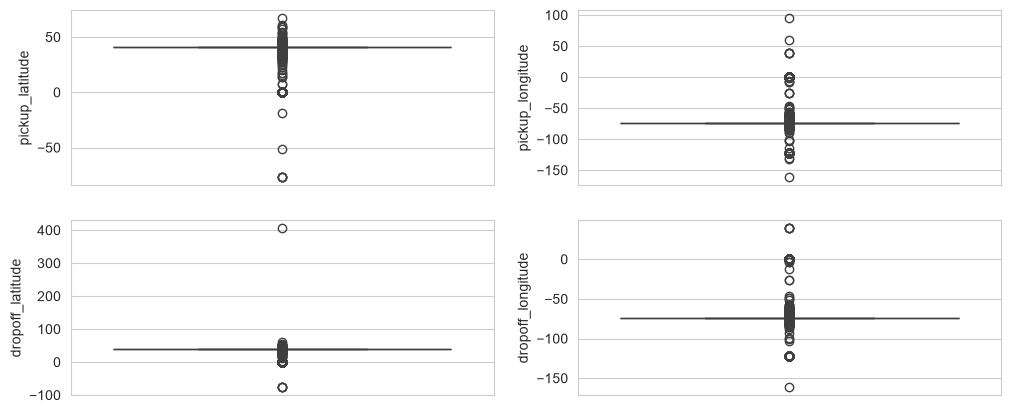

In [ ]:
# boxplots for location based columns

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=2, figsize=(12, 5))
for i in range(4):
    if i <= 1:
        sns.boxplot(y=location_subset.iloc[:, i].compute(), ax=ax1[i])
    else:
        sns.boxplot(y=location_subset.iloc[:, i].compute(), ax=ax2[i - 2])

All the four location based columns contain outliers, thus we are required to remove these outliers.

## Store and Fwd Flag

<Axes: xlabel='count', ylabel='store_and_fwd_flag'>

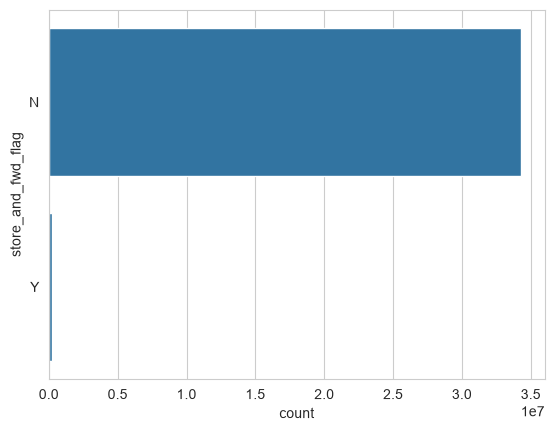

In [39]:
# count plot

sns.countplot(df_final["store_and_fwd_flag"].compute())

There are very little Y where Driver's application was not able to send trip record to the server in time.
We will be dropping the column as it is not relevant for demand prediction.

## Datetime Columns

In [40]:
df_final.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'fare_amount'],
      dtype='str')

In [41]:
# convert the columns to datetime

df_final["tpep_pickup_datetime"] = dd.to_datetime(df_final["tpep_pickup_datetime"], yearfirst=True, format="mixed")
df_final["tpep_dropoff_datetime"] = dd.to_datetime(df_final["tpep_dropoff_datetime"], yearfirst=True, format="mixed")

In [ ]:
# create new columns

df_final["pickup_months"] = df_final["tpep_pickup_datetime"].dt.month
df_final["pickup_day_of_week"] = df_final["tpep_pickup_datetime"].dt.dayofweek
df_final["pickup_hour"] = df_final["tpep_pickup_datetime"].dt.hour
df_final

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,fare_amount,pickup_months,pickup_day_of_week,pickup_hour
npartitions=82,,,,,,,,,,,,,,,
,float64,datetime64[us],datetime64[us],float64,float64,float64,float64,float64,string,float64,float64,float64,int32,int32,int32
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [44]:
df_final.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'fare_amount', 'pickup_months',
       'pickup_day_of_week', 'pickup_hour'],
      dtype='str')

In [45]:
df_final.dtypes

VendorID                        float64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
pickup_longitude                float64
pickup_latitude                 float64
RatecodeID                      float64
store_and_fwd_flag               string
dropoff_longitude               float64
dropoff_latitude                float64
fare_amount                     float64
pickup_months                     int32
pickup_day_of_week                int32
pickup_hour                       int32
dtype: object

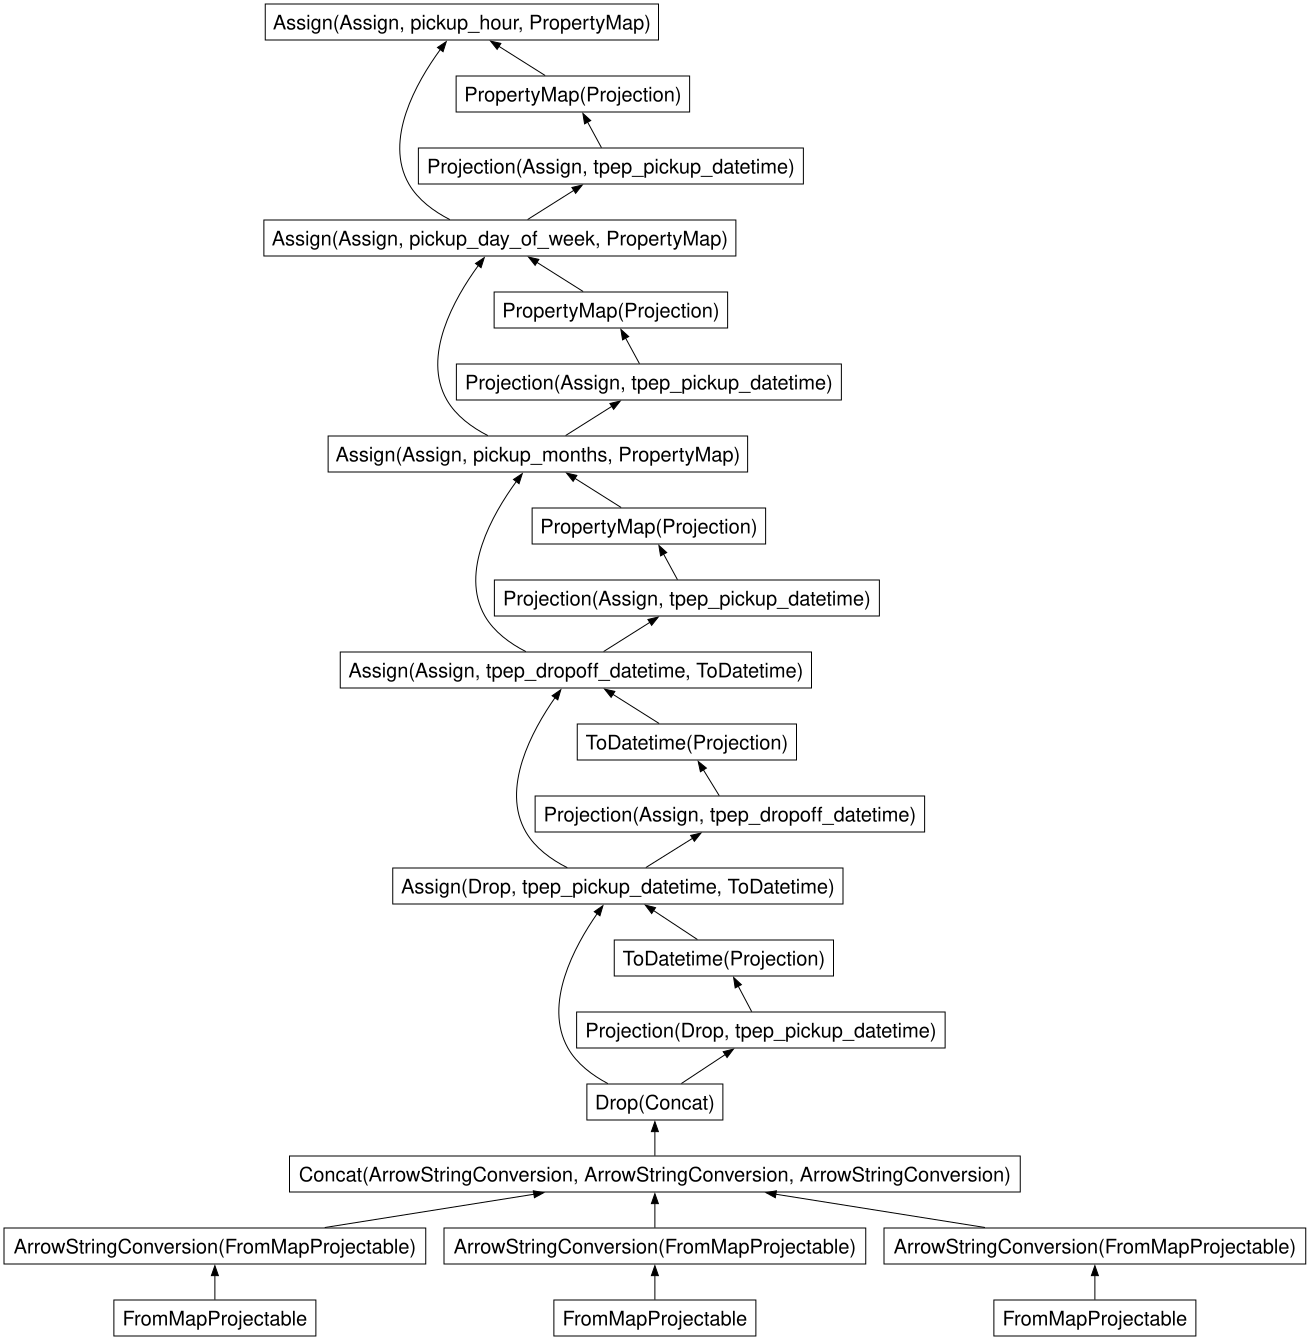

In [46]:
df_final.visualize()

In [ ]:
# plot the number of pickups

pickups_every_3_days = (
                            df_final
                            .set_index('tpep_pickup_datetime')
                            .resample("3D") # set tpep_pickup_datetime as index to resample the data for 3 days intead of 1 day
                            .size()
                            .compute()
)
pickups_every_3_days

tpep_pickup_datetime
2016-01-01     960746
2016-01-04    1007938
2016-01-07    1162789
2016-01-10    1061829
2016-01-13    1192852
2016-01-16    1132536
2016-01-19    1166946
2016-01-22     658061
2016-01-25     968922
2016-01-28    1232734
2016-01-31    1065990
2016-02-03    1176173
2016-02-06    1144752
2016-02-09    1192598
2016-02-12    1285409
2016-02-15    1101217
2016-02-18    1256220
2016-02-21    1114674
2016-02-24    1251497
2016-02-27    1155024
2016-03-01    1208179
2016-03-04    1270530
2016-03-07    1106194
2016-03-10    1273983
2016-03-13    1134075
2016-03-16    1234570
2016-03-19    1176151
2016-03-22    1155525
2016-03-25    1149227
2016-03-28    1108463
2016-03-31     394055
Freq: 3D, dtype: int64

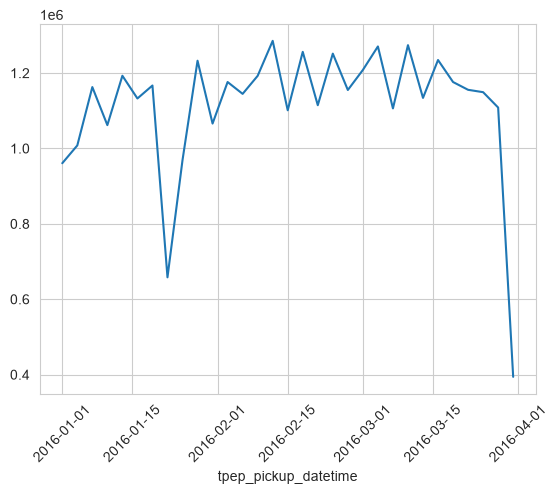

In [49]:
# plot the graph of pickups

sns.lineplot(pickups_every_3_days)
plt.xticks(rotation=45)
plt.show()

- Sudden drop can be observed in number of pickups from 2016-01-22 to 2016-01-25, due to the snowstorm in New York City.
- We can notice a sudden drop in the number of pickups after 2016-03-28 i.e. 2016-03-31. Need to find out.

In [ ]:
# pickups for each hour of the day

pickups_each_hour = (
    df_final
    .groupby(["pickup_hour","pickup_day_of_week"])["VendorID"]
    .count()
    .compute()
)
pickups_each_hour

pickup_hour  pickup_day_of_week
4            2                      29498
             3                      32480
5            2                      49844
6            2                     136330
             3                     138392
                                    ...  
23           5                     299024
0            0                     100903
             1                     101299
19           0                     291911
23           0                     154325
Name: VendorID, Length: 168, dtype: int64

In [ ]:
pickups_each_hour = pickups_each_hour.reset_index()
pickups_each_hour.rename(columns={"VendorID":"Number of Pickups"}, inplace=True)

In [ ]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

replacement_mapper = {k:v for k, v in enumerate(day_names)}
replacement_mapper

{0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

In [ ]:
pickups_each_hour.replace({"pickup_day_of_week":replacement_mapper}, inplace=True)

,pickup_hour,pickup_day_of_week,Number of Pickups
0,4,Wed,29498
1,4,Thu,32480
2,5,Wed,49844
3,6,Wed,136330
4,6,Thu,138392
...,...,...,...
163,23,Sat,299024
164,0,Mon,100903
165,0,Tue,101299
166,19,Mon,291911


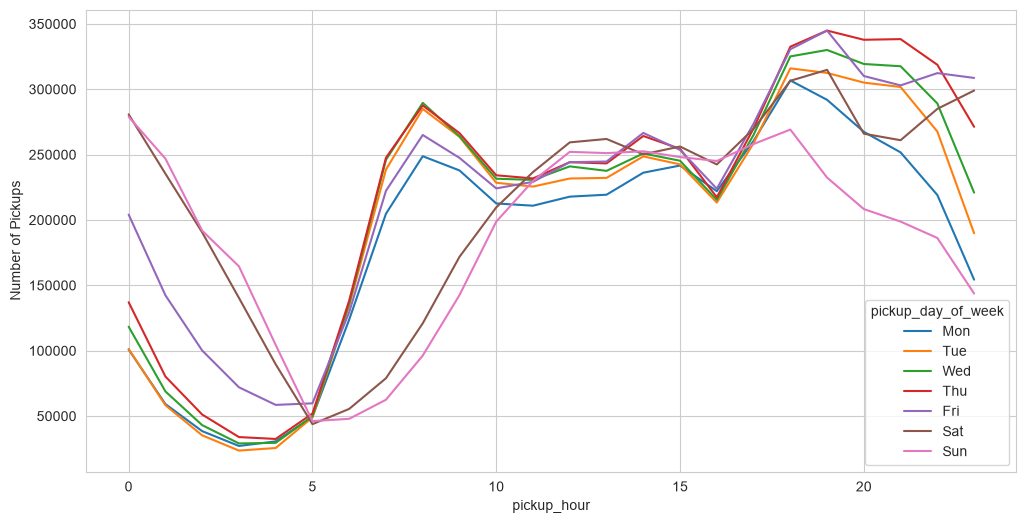

In [ ]:
# plot the lineplot

fig = plt.figure(figsize=(12,6))
sns.lineplot(pickups_each_hour, x="pickup_hour", y="Number of Pickups", hue="pickup_day_of_week", hue_order=day_names)
plt.show()

- It shows Number of Pickups changes with respect to hours of the day and days of the week.
- Working days follow a different pattern than non-working days.
- On working days, pickups decrease from 12 am to 4 am, then pickups increase from 4 am to 8 am, then pickups slightly decreases from 8 to 10 am, then pickups keep at same level till 4 pm, then pickups increase from 4 pm to 7 pm, then pickups decrease from 7 pm to 12 am.
- On non-working days, pickups decrease from 12 am to 5 am, but pickups are higher than working days. then pickups increase from 5 am to 12 pm, but it is less than working days. then pickups move at same level from 12 pm to 5 pm and at same level as working days. then it starts to increase from 5 pm to 7 pm on saturday and 5 pm to 6 pm on sunday and number of pickups is higher on saturday than sunday as next day of sunday is working day. then pickups decrease from 7 pm to 12 am and it is lower than working days. 